In [1]:
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

MANIFEST = "/home/a.kanamarlapudi001/projects/omama-proj/avanith/original_data/hq_4view_manifest.csv"
VIEWS = ["l-cc", "r-cc", "l-mlo", "r-mlo"]
SEED = 42
N = 10  

In [2]:
def show_study(row):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"{row['label']} | {row['study_id']}")
    for ax, view in zip(axes, VIEWS):
        ds = pydicom.dcmread(row[view], force=True)
        ax.imshow(ds.pixel_array, cmap="gray")
        ax.set_title(view)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

label
cancer       10
noncancer    10
Name: count, dtype: int64
cancer 2.25.330024390732943870936460352038066982083


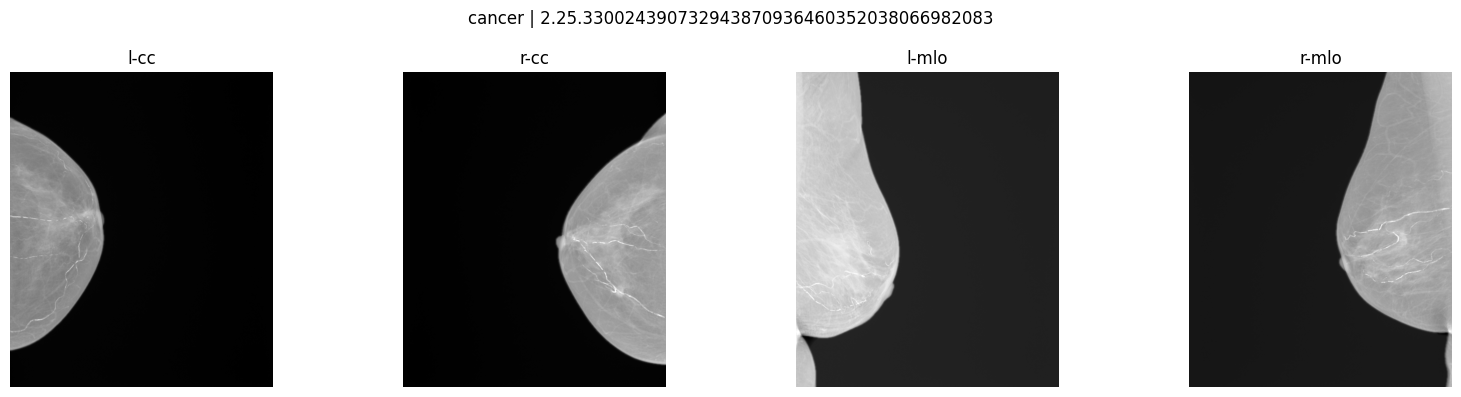

cancer 2.25.307704392937674669607922138533590161435


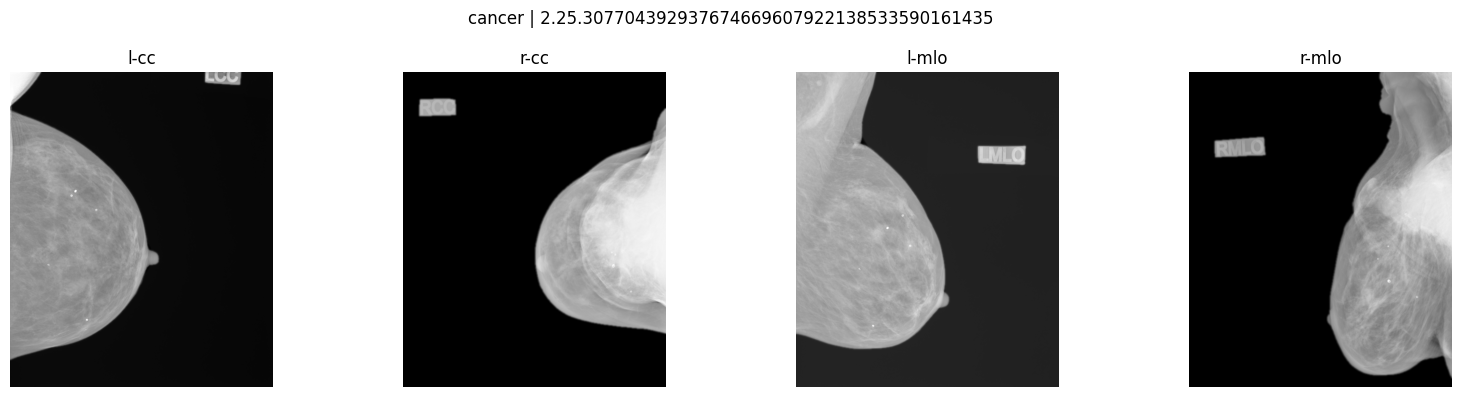

cancer 2.25.313699001597409322228324728605991821164


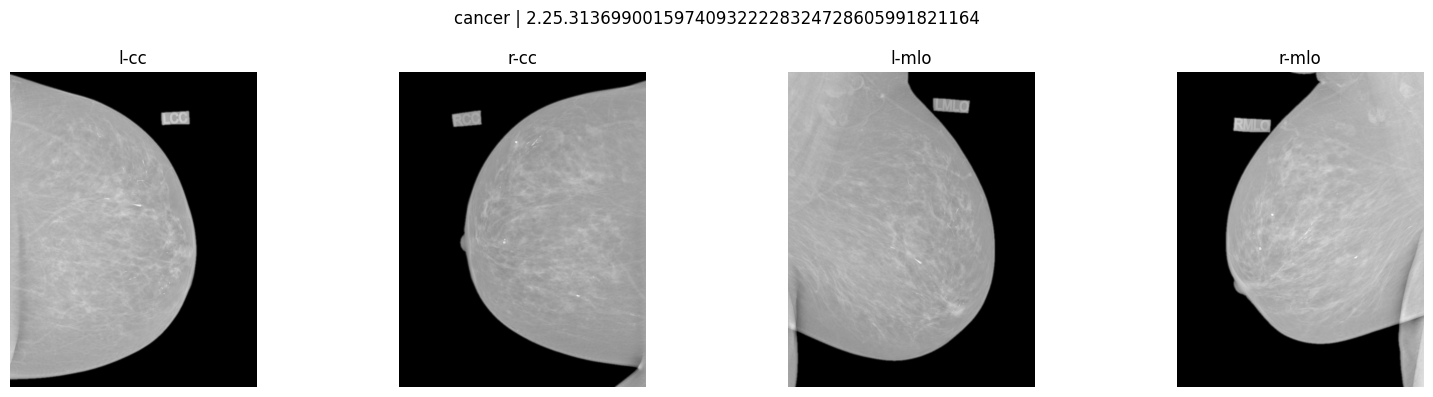

cancer 2.25.149035393451695842872025866959529977546


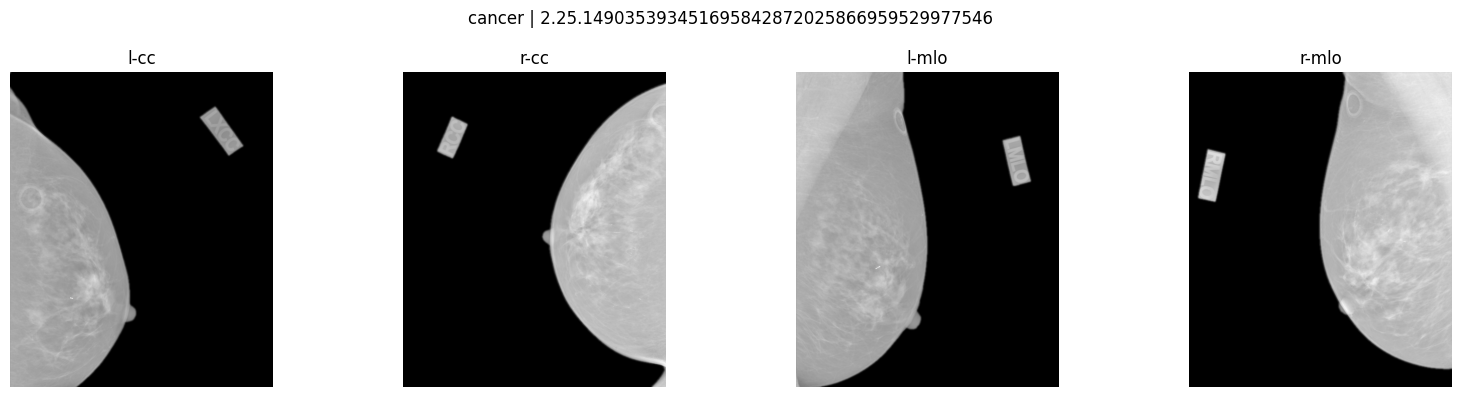

cancer 2.25.296123451017017809027578218870040701515


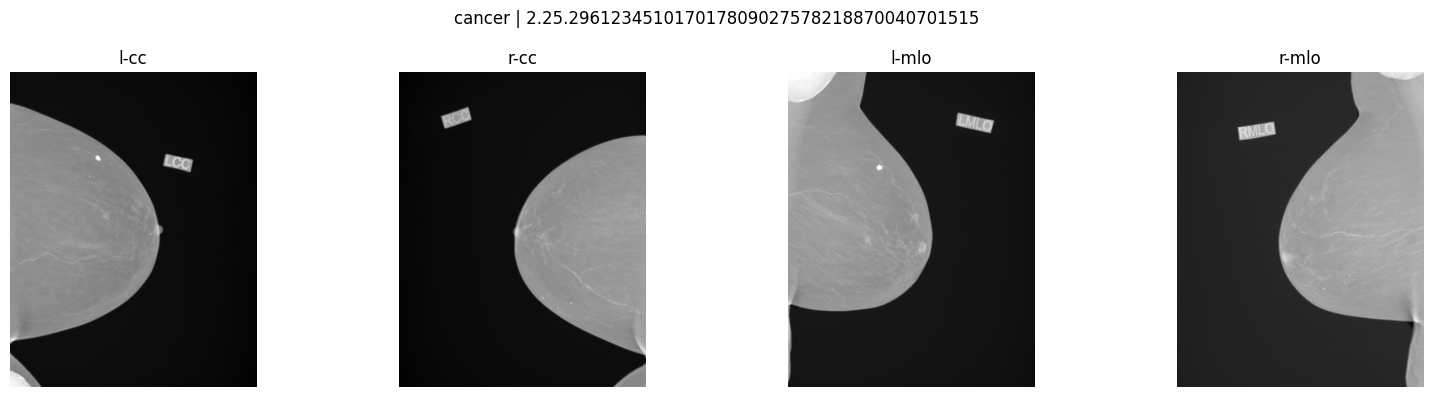

cancer 2.25.231716715965468651338717547960899775136


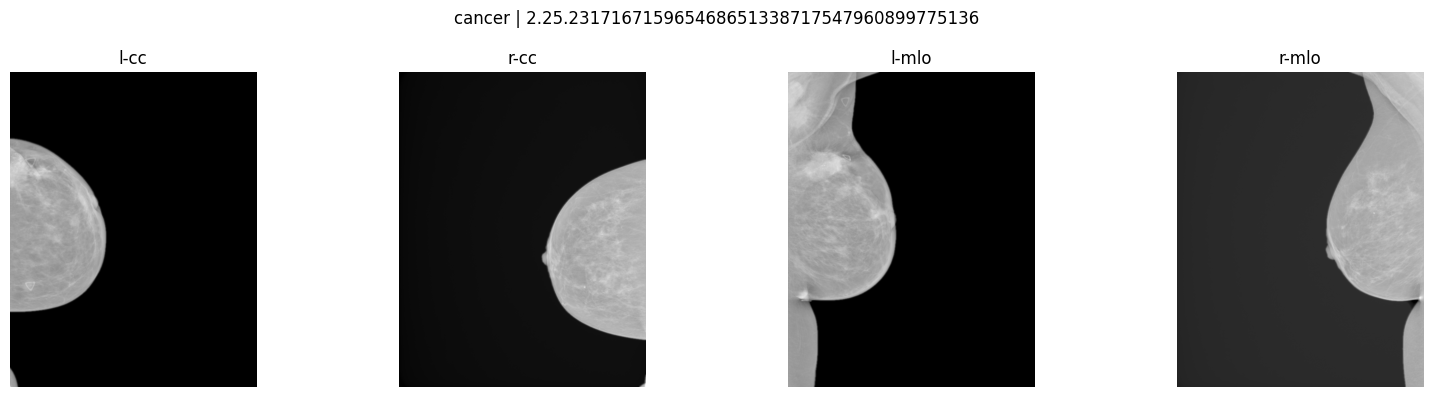

cancer 2.25.67212411001751048538438700515790409090


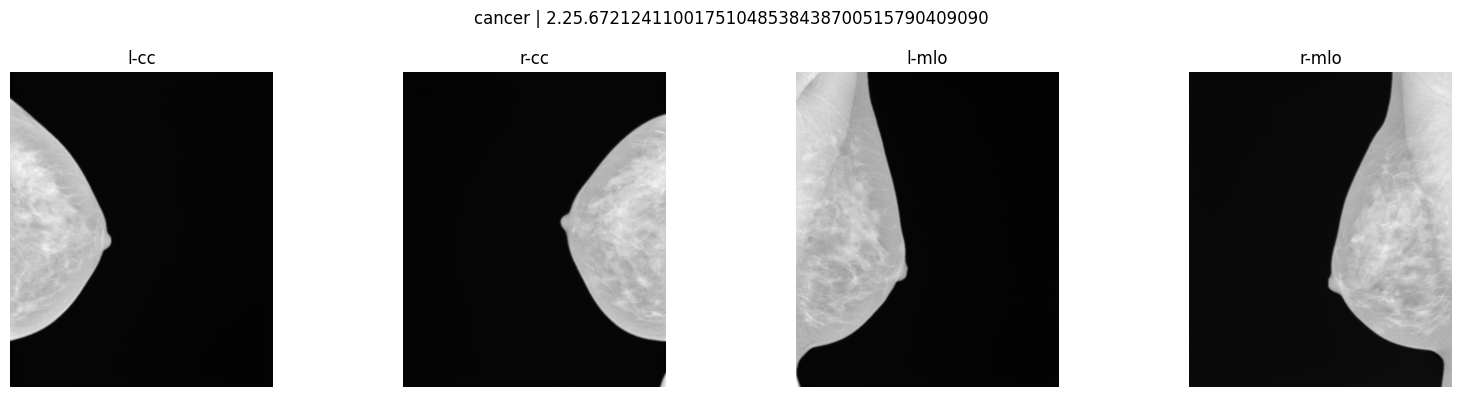

cancer 2.25.37197361632440087020944842524334127702


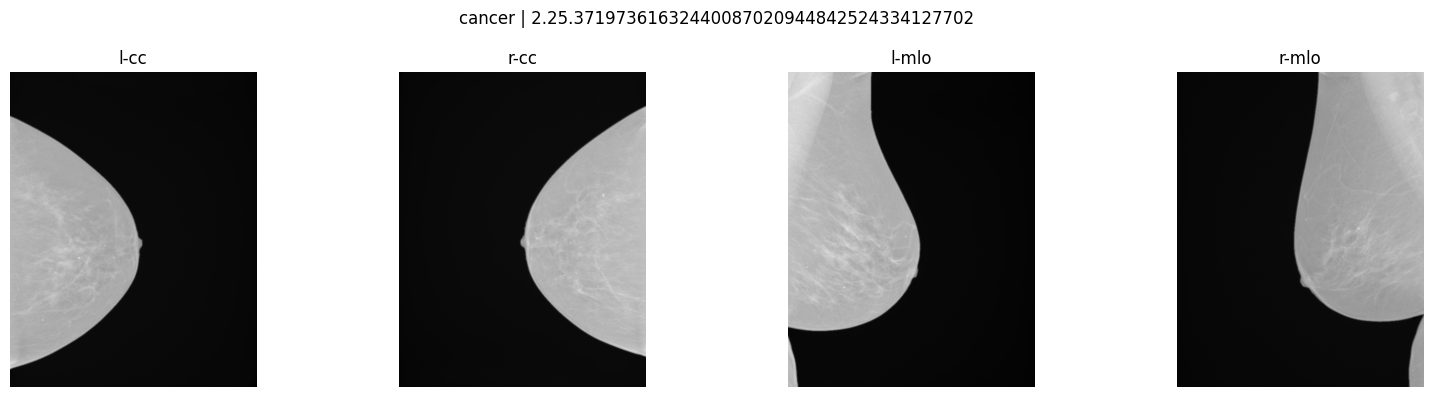

cancer 2.25.109483831220716116219495943541334734259


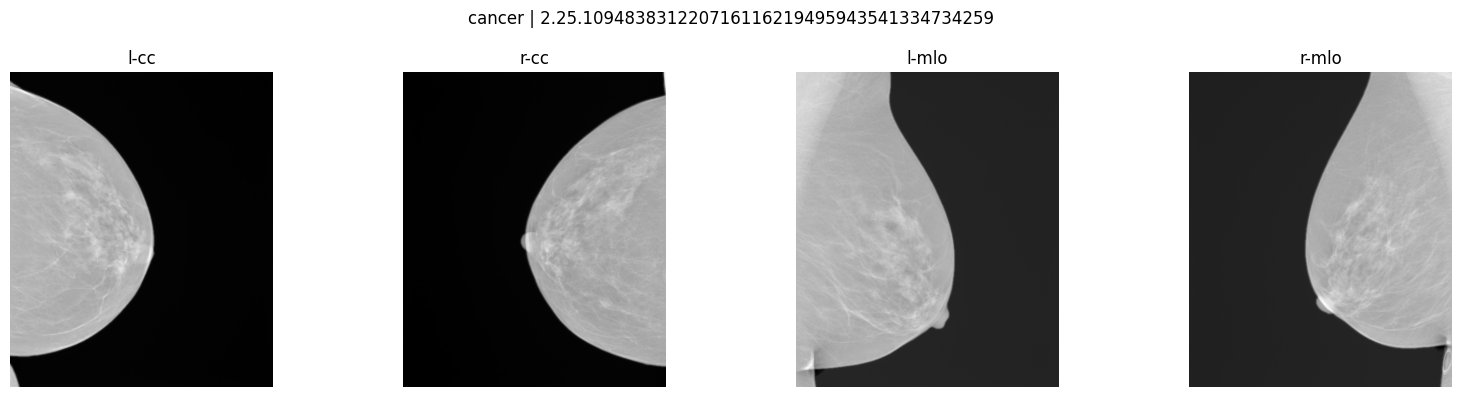

cancer 2.25.105497309178309563018227590004456346421


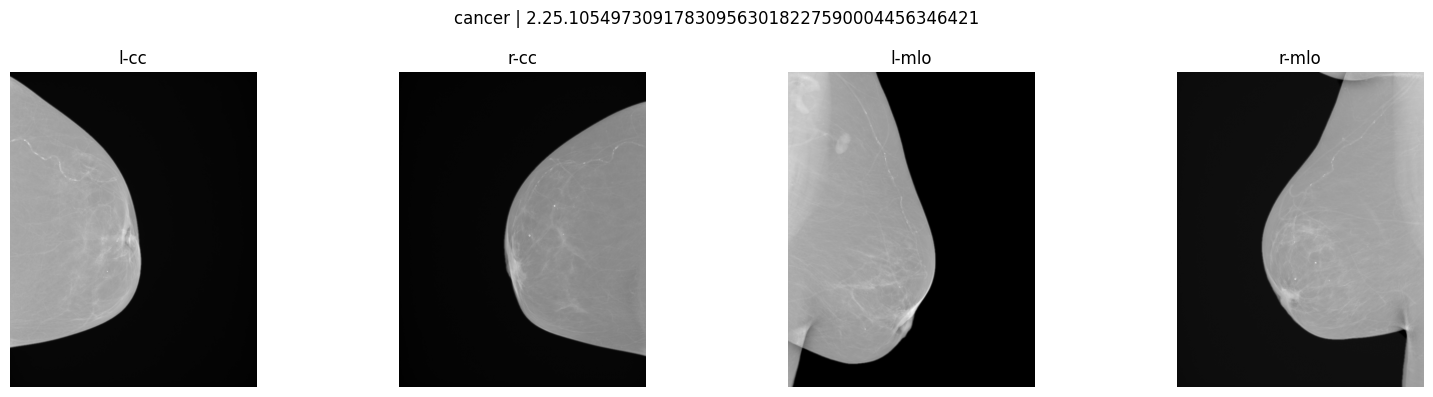

noncancer 2.25.77579392103469315812148869958730799162


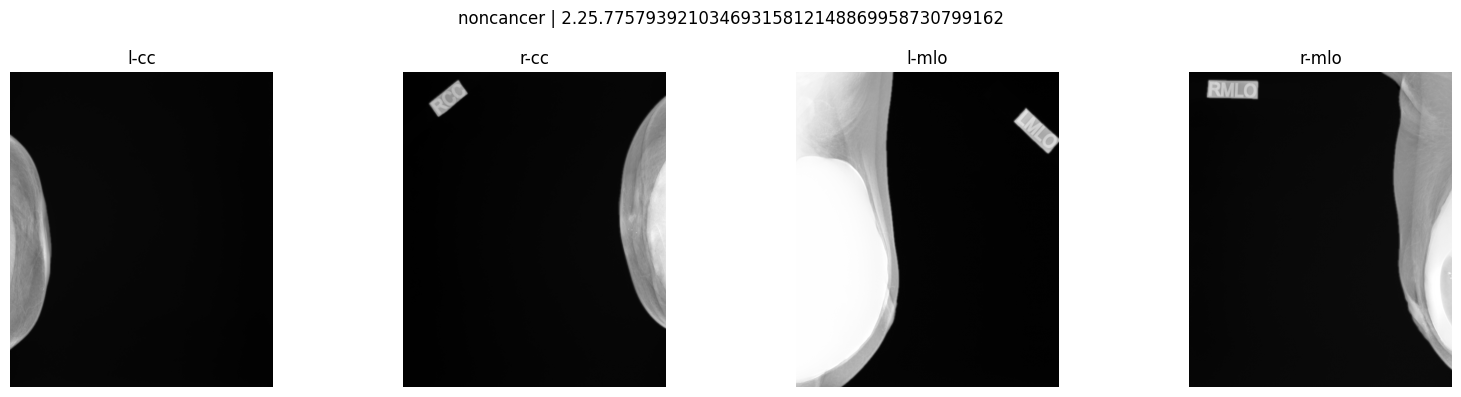

noncancer 2.25.335012228000685092847792292082192463745


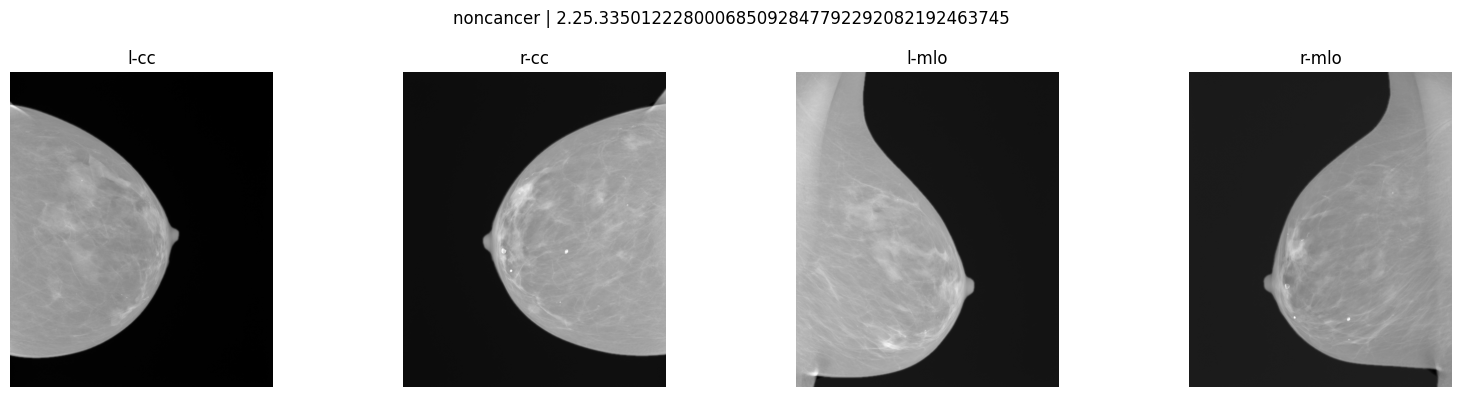

noncancer 2.25.323839199660041411291015693186135001949


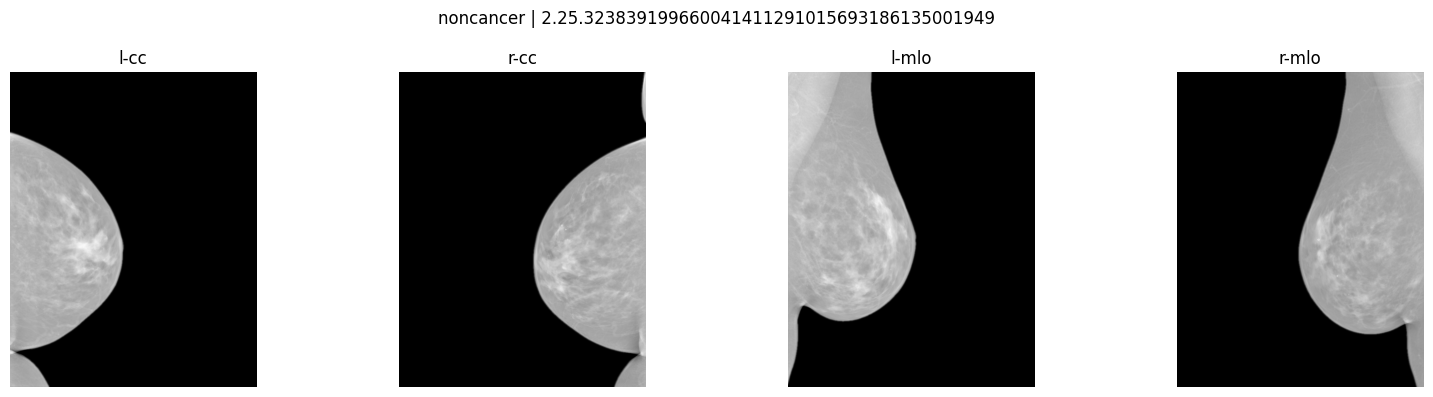

noncancer 2.25.215744665123833347606889983755836792958


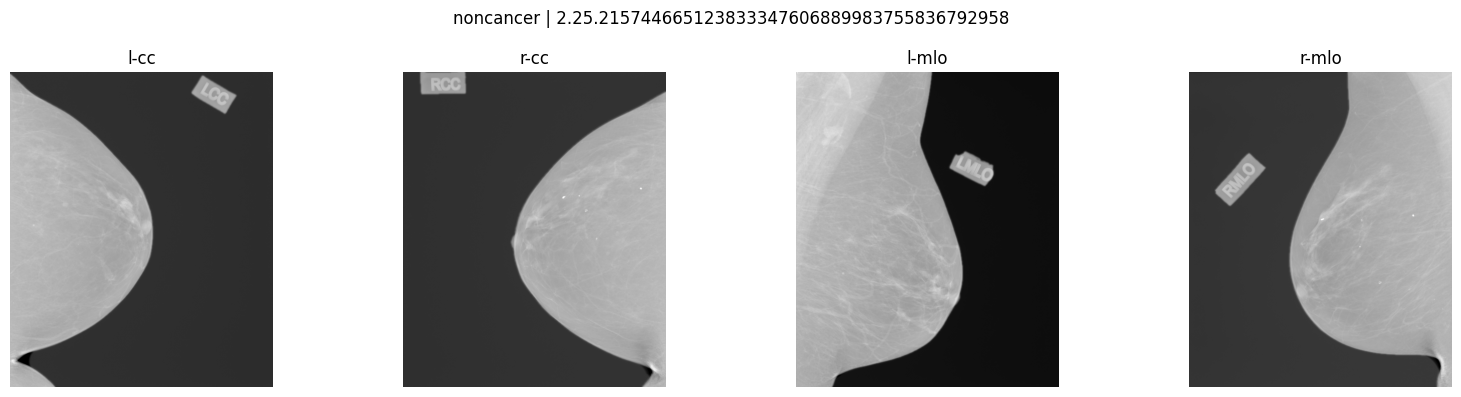

noncancer 2.25.236303162037074056417083332631523314203


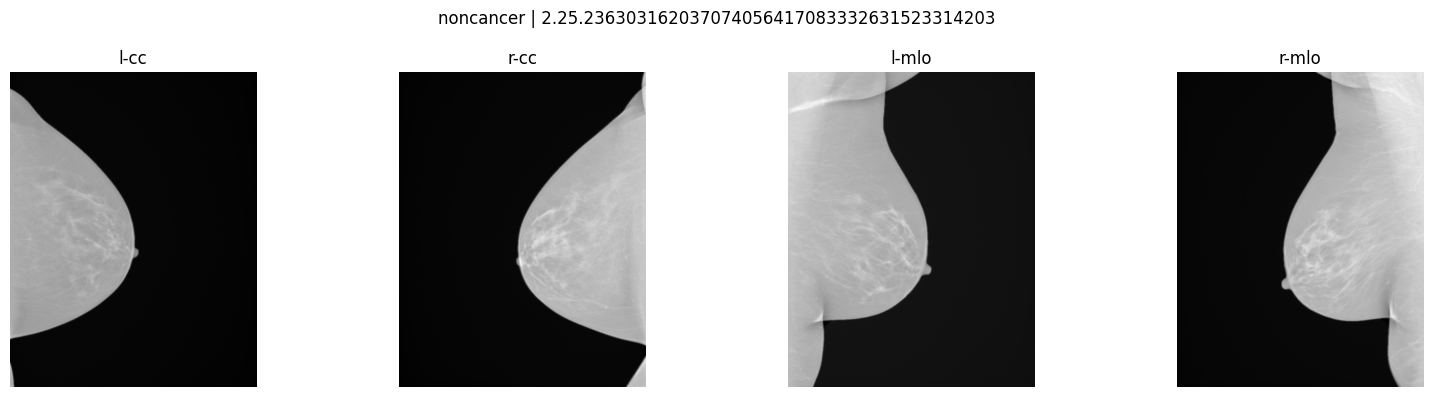

noncancer 2.25.263550449573369073327950470874361683771


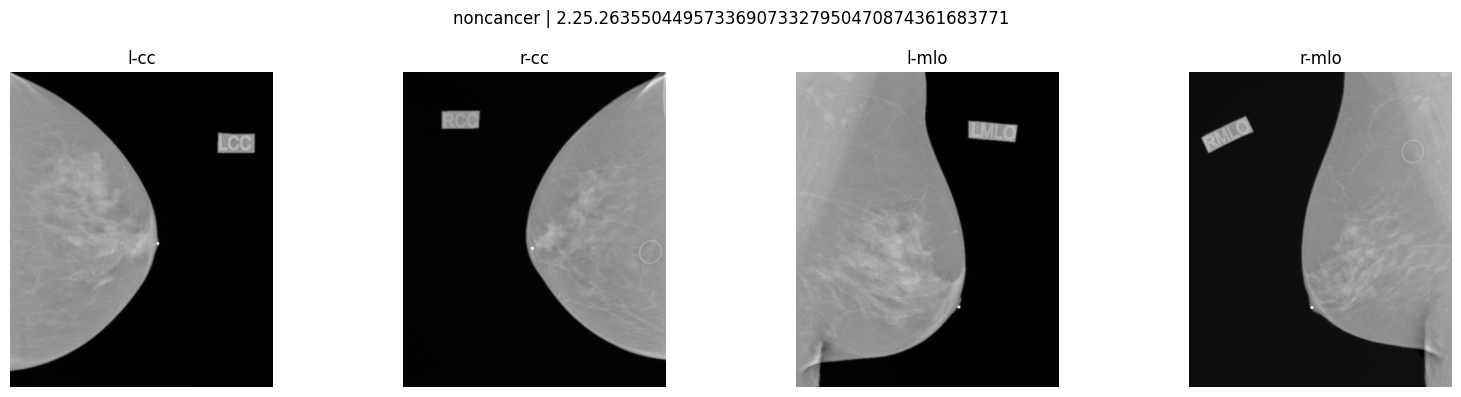

noncancer 2.25.276008747674855791851794639447479272893


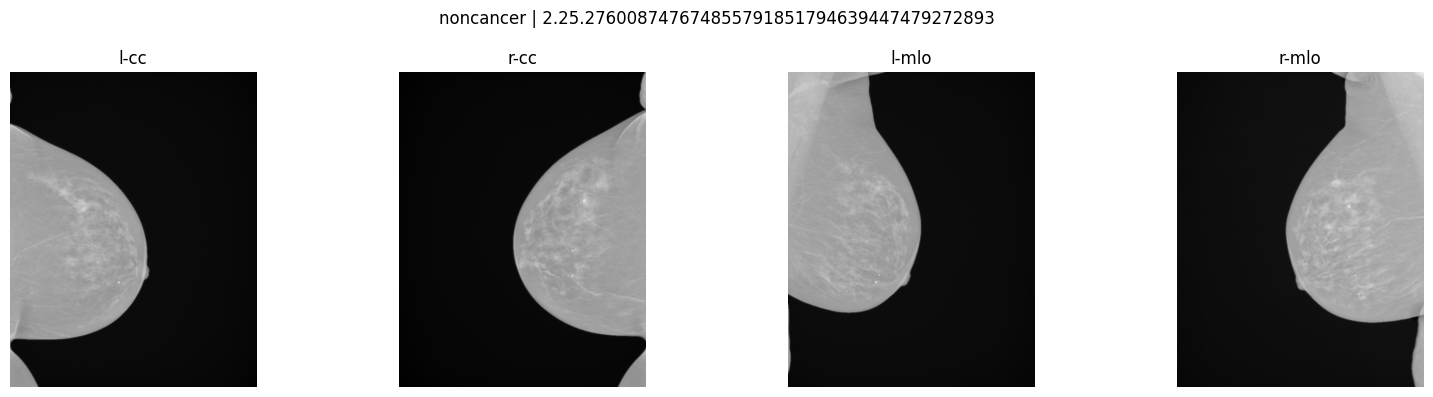

noncancer 2.25.333201232076282989832606297989485700707


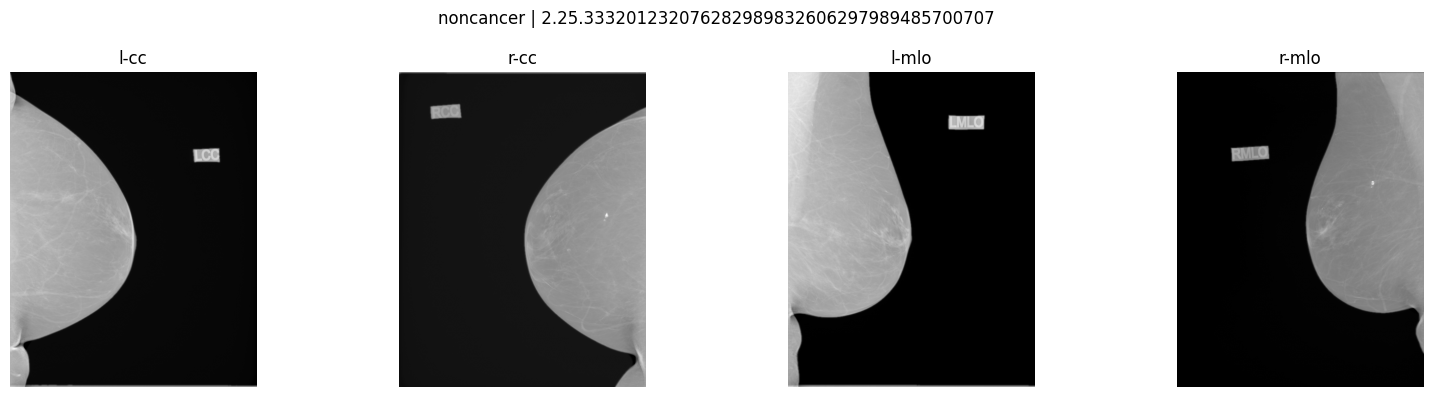

noncancer 2.25.236578576751813178960545479244496542516


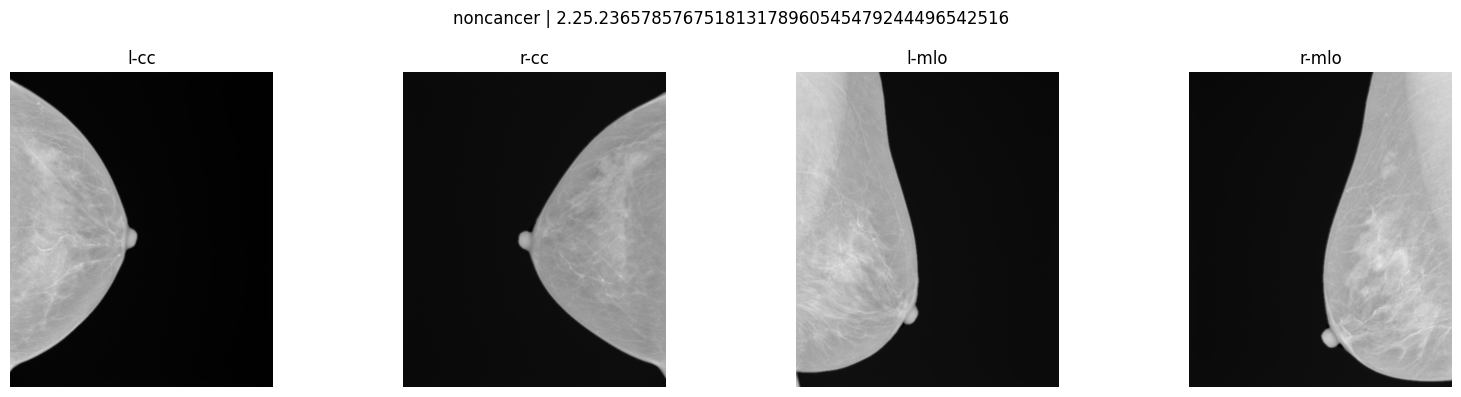

noncancer 2.25.72579821401953544310379904762480535603


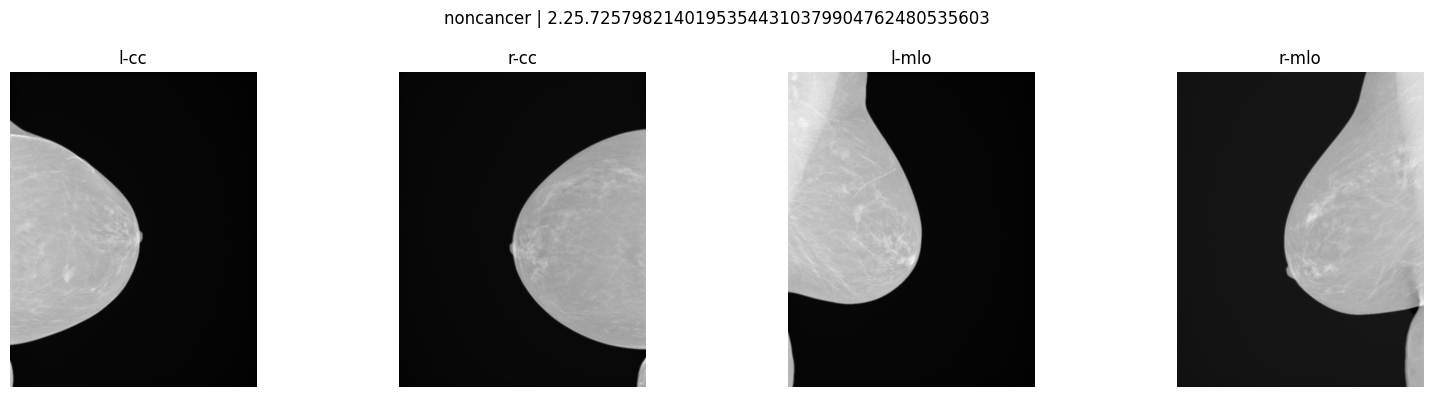

In [3]:
df = pd.read_csv(MANIFEST)

cancer = df[df["label"] == "cancer"].sample(N, random_state=SEED)
noncancer = df[df["label"] == "noncancer"].sample(N, random_state=SEED)
sample = pd.concat([cancer, noncancer])

print(sample["label"].value_counts())

for _, row in sample.iterrows():
    print(row["label"], row["study_id"])
    show_study(row)